# Multi-energy multimode phase retrieval parallel
Minimal use of `phase_retrieval_core_multienergy_multimode_parallel.py`.

In [1]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sys, os
from os.path import join
sys.path.append("/home/user/Moritz/msc/RB2004/code/FTH-Phase_Retrieval/library")
import phase_retrieval_core_multienergy as phr_me
import phase_retrieval_core_multienergy_multimode_parallel as pr

In [2]:
data = np.load(Path("/home/user/Moritz/msc/RB2004/data.npz"))
holograms = data["holograms"]
energy_ev = data["energy"]
mask_pixel = data["mask_pixel"]
supportmask = np.load("/home/user/Moritz/msc/RB2004/suppmask.npz.npy")

optical_constants = np.load(Path("/home/user/Moritz/msc/RB2004/data/refractive_index_constraints.npz"))
constraint_energy_ev = optical_constants["energy_ev"]
beta = optical_constants["beta"]
delta = optical_constants["delta"]

#if not np.allclose(energy_ev, constraint_energy_ev):
beta = np.interp(energy_ev, constraint_energy_ev, beta)
delta = np.interp(energy_ev, constraint_energy_ev, delta)

assert holograms.shape[0] == energy_ev.size == beta.size == delta.size
assert supportmask.shape == holograms.shape[1:]

In [3]:
bin_factor = 2
support_crop_pad = bin_factor
supportmask = np.load("/home/user/Moritz/msc/RB2004/suppmask.npz.npy")


def _bin_2d(array, factor, reducer="mean"):
    array = np.asarray(array)
    if array.ndim != 2:
        raise ValueError("Expected a 2D array.")
    if factor <= 0:
        raise ValueError("bin_factor must be a positive integer.")

    height, width = array.shape
    trimmed_height = height - (height % factor)
    trimmed_width = width - (width % factor)
    array = array[:trimmed_height, :trimmed_width]
    reshaped = array.reshape(
        trimmed_height // factor,
        factor,
        trimmed_width // factor,
        factor,
    )

    if reducer == "mean":
        return reshaped.mean(axis=(1, 3))
    if reducer == "max":
        return reshaped.max(axis=(1, 3))
    raise ValueError("reducer must be 'mean' or 'max'.")


def _bin_stack(stack, factor, reducer="mean"):
    stack = np.asarray(stack)
    if stack.ndim == 2:
        return _bin_2d(stack, factor, reducer=reducer)
    if stack.ndim != 3:
        raise ValueError("Expected a 2D image or 3D energy stack.")
    return np.stack([
        _bin_2d(image, factor, reducer=reducer) for image in stack
    ])


def _support_crop_slices(supportmask, pad, factor):
    supportmask = np.asarray(supportmask)
    support_pixels = np.argwhere(supportmask > 0)
    if not support_pixels.size:
        return (slice(None), slice(None))

    row_min, col_min = support_pixels.min(axis=0)
    row_max, col_max = support_pixels.max(axis=0) + 1
    height, width = supportmask.shape

    row_min = max(0, row_min - pad)
    col_min = max(0, col_min - pad)
    row_max = min(height, row_max + pad)
    col_max = min(width, col_max + pad)

    c0, c1 = (row_min + row_max) /2, (col_min + col_max) /2

    return c0, c1


c0, c1 = _support_crop_slices(
    np.load("/home/user/Moritz/msc/RB2004/suppmask.npz.npy"),
    support_crop_pad,
    bin_factor,
)


def center_and_crop(img, c0, c1, frac=0.5):
    center0, center1 = img.shape[0] // 2, img.shape[1] // 2
    shift0, shift1 = int(center0 - np.round(c0)), int(center1 - np.round(c1))
    shifted = np.roll(img, (shift0, shift1), axis=(0, 1))

    h = int(img.shape[0] * frac)//2
    w = int(img.shape[1] * frac)//2
    
    return shifted[(img.shape[0] // 2) -h:(img.shape[0] // 2) + h, (img.shape[1] // 2) - w:(img.shape[1] // 2) + w]


In [4]:

supportmask = center_and_crop(supportmask, c0, c1, frac=0.5)

holograms = _bin_stack(
    data["holograms"],
    bin_factor,
    reducer="mean",
)
mask_pixel = _bin_stack(
    data["mask_pixel"],
    bin_factor,
    reducer="max",
)

supportmask = (supportmask > 0).astype(supportmask.dtype)

assert holograms.shape[0] == energy_ev.size == beta.size == delta.size
assert supportmask.shape == holograms.shape[1:]
assert mask_pixel.shape == holograms.shape


  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/asyncio/base_events.py", line 604, in run_forever
    self._run_once()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/asyncio/base_events.py", line 1909, in _run_once
    handle._run()
  File "/home/user/m

interactive(children=(FloatRangeSlider(value=(9.491102234684877, 81410.19737861928), description='contrast', l…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

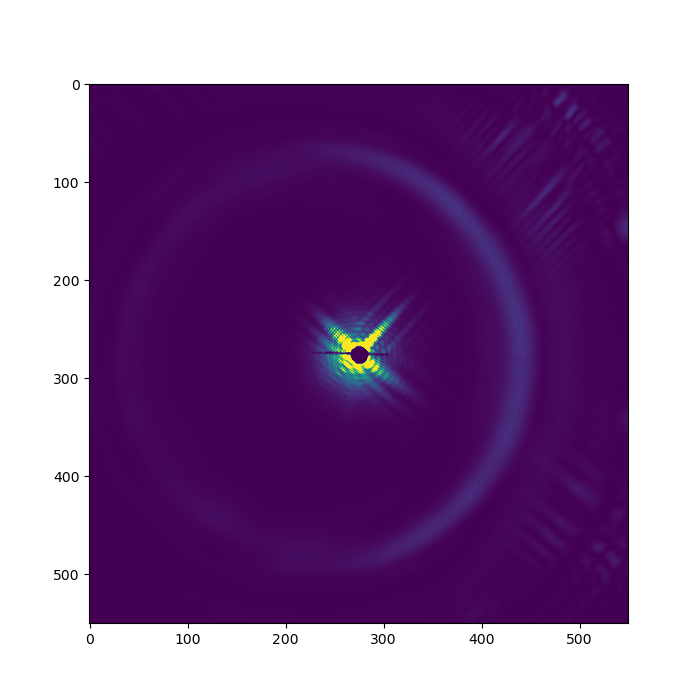

In [5]:
from interactive import cimshow
%matplotlib widget
cimshow(holograms)

In [6]:
import cupy as cp
import numpy as np

if not hasattr(cp, 'errstate'):
    cp.errstate = np.errstate

In [ ]:
from importlib import reload
reload(pr)
recipe = {
    # Per-energy multimode update schedule.
    "inner_mode": ["HAPRE", "ER"],       # Algorithm stages at every energy.
    "inner_Nit": [700, 50],               # Iterations in each stage.
    "outer_iterations": 10,              # Number of update-plus-projection cycles.
    "warmup_mode": ["HAPRE", "ER"],      # Independent pre-coupling stages.
    "warmup_Nit": [700, 50],                      # Zero disables warmup.
    "shuffle_energies": True,             # Randomize energy order each outer cycle.
    "random_seed": None,                  # Seed for energy-order randomization.
    "beta_zero": 0.5,                     # Beta value(s), broadcast or one per stage.
    "beta_mode": "arctan",               # Beta schedule name(s) or arrays.
    "alpha_zero": 0.0,                    # TV strength; zero disables TV.
    "alpha_mode": "const",               # Alpha schedule name(s) or arrays.
    "TV_freq": 1e9,                       # TV update interval.
    "warmup_beta_zero": None,             # None inherits the inner setting.
    "warmup_beta_mode": None,             # None inherits the inner setting.
    "warmup_alpha_zero": None,            # None inherits the inner setting.
    "warmup_alpha_mode": None,            # None inherits the inner setting.
    "warmup_TV_freq": None,               # None inherits the inner setting.
    "plot_every": 1e9,                    # Error sampling/plot interval.
    "average_img": 1,                     # Number of best late iterates to average.
    "Fourier_last": True,                 # Finish each stage with its Fourier constraint.
    "final_fourier_constraint": True,     # Enforce measured summed modal intensity at the end.
    "hologram_intensity_cutoff_vmin": -1, # Percentile baseline subtraction.
    # Cross-energy projection applied independently to every mode.
    "projection_model": "rank1_spectral",           # "none", "svd", or "rank1_spectral".
    "rank": 1,                            # SVD residual rank.
    "projection_every": 6,                # Projection interval in outer cycles.
    "projection_relaxation": 1.0,         # Projection blending fraction.
    "projection_constraints_inside_support_only": False, # If True, apply joint projections only inside supportmask.
    "projection_start": 0,                # First cycle eligible for projection.
    "projection_static_mode": "mean",    # "mean", "first", or "none".
    "energy_weights": None,               # Positive weight per energy.
    "log_floor": 1e-12,                   # Magnitude floor before complex log.
    "spectral_constraint": "known_beta",       # Rank-one spectrum: free, KK, or known-beta modes.
    "energy_values": None,                # Strictly increasing energies for KK constraints.
    "known_beta_spectrum": beta,          # Known absorption-like spectrum.
    "known_delta_spectrum": None,         # Optional known dispersion-like spectrum.
    "absorption_part": "real",           # Absorption location in the complex coefficient.
    "kk_sign": 1.0,                       # KK sign convention.
    "kk_subtract_baseline": True,         # Remove endpoint baseline before KK.
    "kk_normalize_input": False,          # Normalize absorption before KK.
    "known_beta_normalization": "none",  # none, maxabs, l2, or std.
    "fit_known_beta_scale": True,         # Fit known-spectrum scale.
    "fit_known_beta_offset": True,        # Fit known-spectrum offset.
    # Multimode-only controls.
    "Nmodes": 1,                          # Number of mutually incoherent modes per energy.
    "mode_initialization_seed": 0,        # Seed used to break initial modal degeneracy.
}

fields, fieldswarmup, components, bsmasks, errors = (
    pr.multi_energy_phase_retrieval_algorithm(
        holograms,
        mask_pixel,
        supportmask,
        multi_energy_recipe=recipe,
    )
)

Outer 0: completed update 1 for energy 9 (no projection due)
Outer 0: completed update 2 for energy 0 (no projection due)
Outer 0: completed update 3 for energy 13 (no projection due)
Outer 0: completed update 4 for energy 3 (no projection due)
Outer 0: completed update 5 for energy 14 (no projection due)
Outer 0: projection applied after update 6 for energy 1 - model=rank1_spectral, Nmodes=1, rank=1, spectral_constraint=known_beta
Outer 0: completed update 7 for energy 8 (no projection due)
Outer 0: completed update 8 for energy 4 (no projection due)
Outer 0: completed update 9 for energy 11 (no projection due)
Outer 0: completed update 10 for energy 5 (no projection due)
Outer 0: completed update 11 for energy 6 (no projection due)
Outer 0: projection applied after update 12 for energy 2 - model=rank1_spectral, Nmodes=1, rank=1, spectral_constraint=known_beta
Outer 0: completed update 13 for energy 10 (no projection due)
Outer 0: completed update 14 for energy 12 (no projection due)


interactive(children=(FloatRangeSlider(value=(0.00012209483520967464, 1.033150481988374), description='contras…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

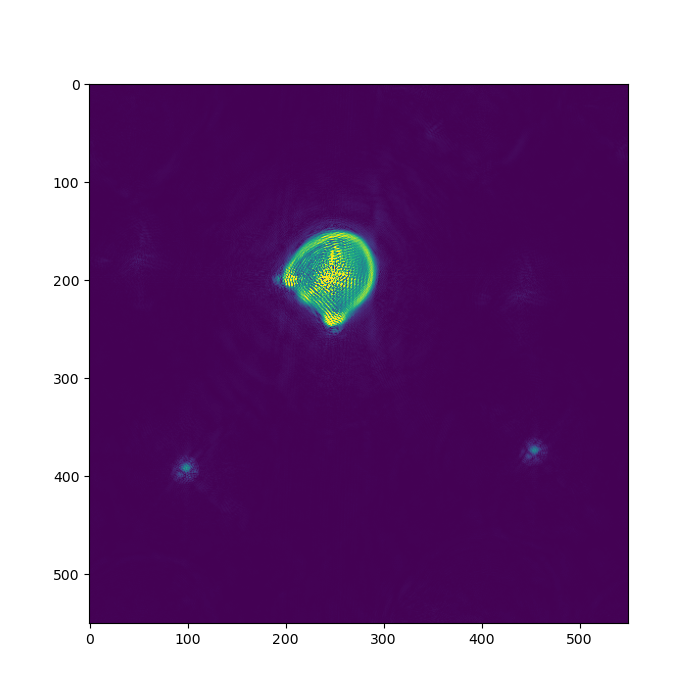

In [9]:
import interactive
from interactive import cimshow
%matplotlib widget
cimshow(np.abs(interactive.reconstruct(fields[:, :, :])))

In [ ]:
components.get('spectral_spatial_map')

In [ ]:
components.keys()

/home/user/Moritz/msc/RB2004/code/FTH-Phase_Retrieval/library/interactive.py:181: ComplexWarning: Casting complex values to real discards the imaginary part
  im = np.array(im).astype("float")


interactive(children=(FloatRangeSlider(value=(-14.983211433125758, 14.82813094617413), description='contrast',…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

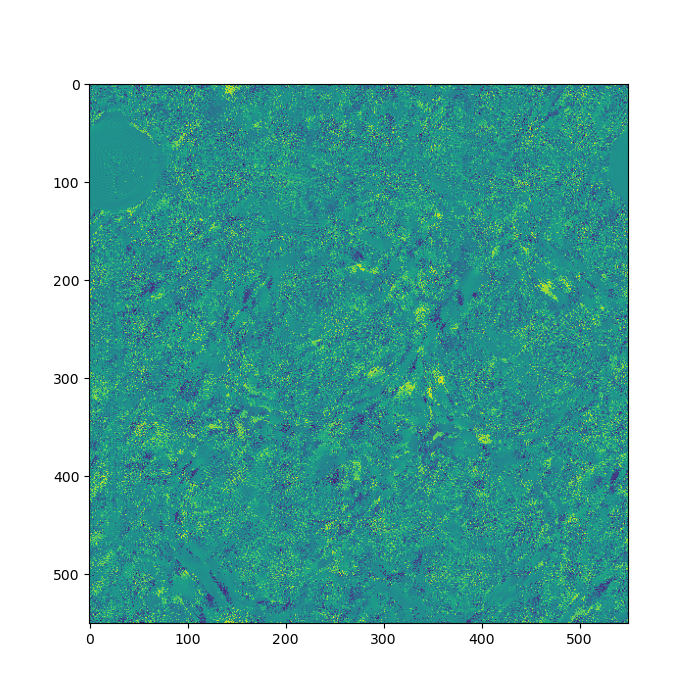

In [10]:
cimshow(components['mode_components'][0]['spectral_spatial_map'])

interactive(children=(FloatSlider(value=0.0, description='propagation[um]', layout=Layout(width='75%'), min=-1…

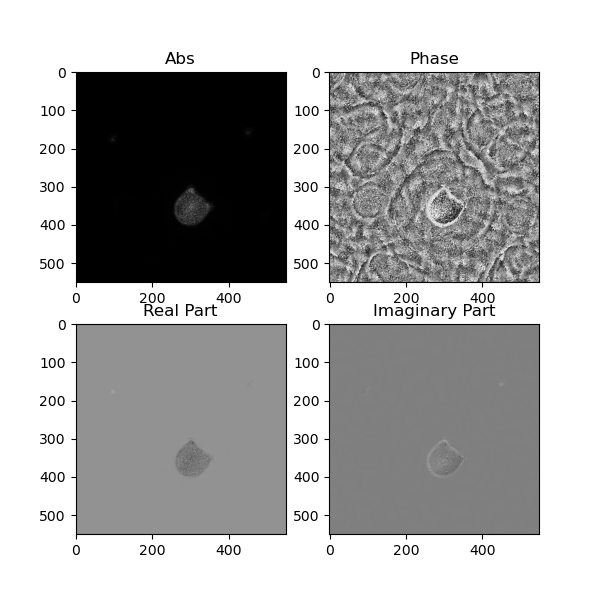

In [22]:
i = 4
_ = interactive.focusCDI((fields[i, :, :]), (fields[i, :, :]), roi = np.s_[:,:], mask = np.ones_like(fields[i, :, :]), max_prop_dist=100)

interactive(children=(FloatRangeSlider(value=(3.1207692356466206, 391.71256947241255), description='contrast',…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

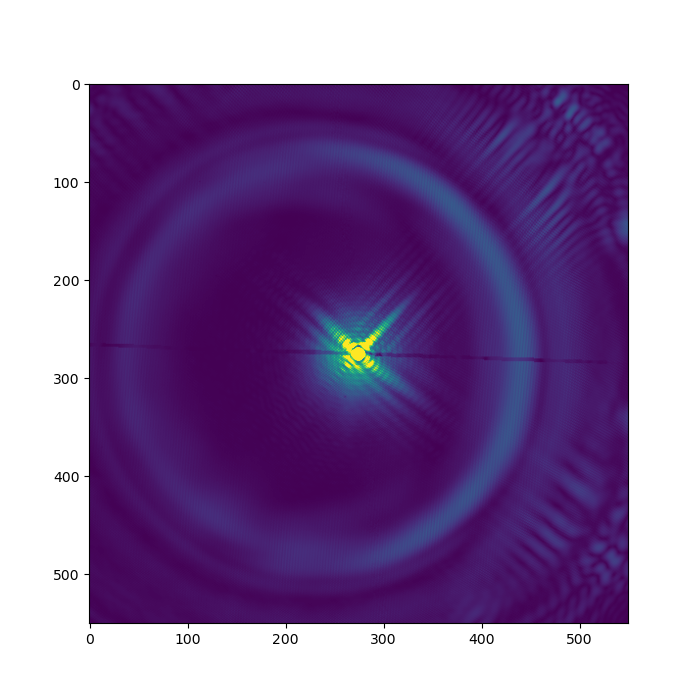

In [24]:
cimshow(np.abs(fields[:, :, :]))